In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path("../data/processed")
RAW = Path("../data/raw")

nav = pd.read_csv(RAW / "02_nav_history.csv", parse_dates=["date"])
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

txn = pd.read_csv(PROCESSED / "clean_transactions.csv", parse_dates=["transaction_date"])
perf = pd.read_csv(PROCESSED / "clean_performance.csv")

print("Loaded")
print(nav.shape, txn.shape)

Loaded
(46000, 4) (32778, 13)


VaR done
   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


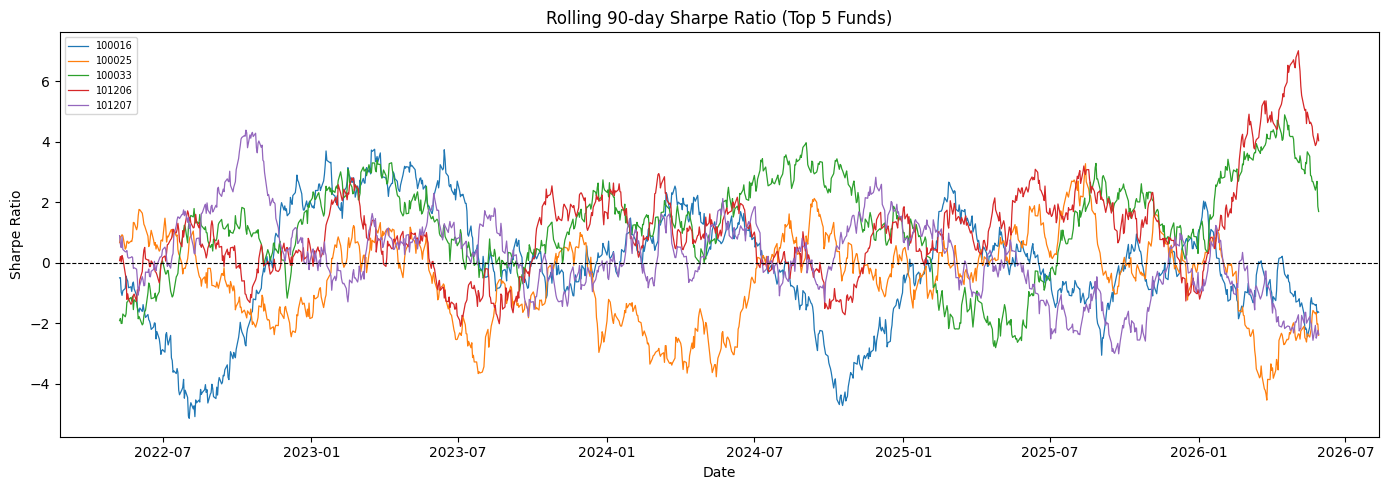

Rolling Sharpe done


In [2]:
# ── TASK 1: VaR and CVaR ─────────────────────────────────────────────
var_rows = []
for code, grp in nav.groupby("amfi_code"):
    returns = grp["daily_return"].dropna()
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_rows.append({
        "amfi_code": code,
        "VaR_95": round(var_95, 6),
        "CVaR_95": round(cvar_95, 6)
    })

var_df = pd.DataFrame(var_rows)
var_df.to_csv(PROCESSED / "var_cvar_report.csv", index=False)
print("VaR done")
print(var_df.head())

# ── TASK 2: Rolling 90-day Sharpe ────────────────────────────────────
Rf = 0.065 / 252
top5 = nav["amfi_code"].value_counts().head(5).index.tolist()

plt.figure(figsize=(14,5))
for code in top5:
    grp = nav[nav["amfi_code"]==code].sort_values("date")
    rolling_sharpe = (
        (grp["daily_return"] - Rf).rolling(90).mean() /
        grp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)
    plt.plot(grp["date"], rolling_sharpe, label=str(code), linewidth=0.9)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Rolling 90-day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(PROCESSED / "rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Rolling Sharpe done")

In [3]:
# ── TASK 3: Investor Cohort Analysis ─────────────────────────────────
print("TXN cols:", txn.columns.tolist())
txn["year"] = txn["transaction_date"].dt.year
cohort = txn.groupby("year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    num_transactions=("amount_inr", "count")
).reset_index()
cohort.to_csv(PROCESSED / "cohort_analysis.csv", index=False)
print("Cohort Analysis:")
print(cohort)

# ── TASK 4: SIP Continuity Analysis ──────────────────────────────────
sip_txn = txn[txn["transaction_type"] == "SIP"].sort_values(["folio_number", "transaction_date"])
sip_txn["gap_days"] = sip_txn.groupby("folio_number")["transaction_date"].diff().dt.days
sip_summary = sip_txn.groupby("folio_number").agg(
    sip_count=("transaction_date", "count"),
    avg_gap=("gap_days", "mean")
).reset_index()
sip_summary["at_risk"] = (sip_summary["sip_count"] >= 6) & (sip_summary["avg_gap"] > 35)
sip_summary.to_csv(PROCESSED / "sip_continuity.csv", index=False)
print(f"\nSIP at-risk investors: {sip_summary['at_risk'].sum()}")

# ── TASK 5: Fund Recommender ──────────────────────────────────────────
sharpe_df = pd.read_csv(PROCESSED / "sharpe_values.csv")
perf_cols = perf.columns.tolist()
print("\nPerf cols:", perf_cols)

def recommend_funds(risk_appetite):
    risk_map = {"Low": (0, 0.5), "Moderate": (0.5, 1.0), "High": (1.0, 999)}
    low, high = risk_map[risk_appetite]
    filtered = sharpe_df[
        (sharpe_df["sharpe_ratio"] >= low) & 
        (sharpe_df["sharpe_ratio"] < high)
    ].sort_values("sharpe_ratio", ascending=False).head(3)
    return filtered

print("\nLow risk recommendations:")
print(recommend_funds("Low"))
print("\nModerate risk recommendations:")
print(recommend_funds("Moderate"))
print("\nHigh risk recommendations:")
print(recommend_funds("High"))

# ── TASK 6: Sector HHI ───────────────────────────────────────────────
holdings = pd.read_csv(PROCESSED / "clean_portfolio_holdings.csv")
print("\nHoldings cols:", holdings.columns.tolist())

TXN cols: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
Cohort Analysis:
     year  avg_sip_amount  total_invested  num_transactions
0  2024.0   107659.763778       996283454              9254
1  2025.0   106781.954665       405130736              3794


KeyError: 'folio_number'

In [4]:
# ── TASK 4: SIP Continuity Analysis ──────────────────────────────────
sip_txn = txn[txn["transaction_type"] == "SIP"].sort_values(["investor_id", "transaction_date"])
sip_txn = sip_txn.copy()
sip_txn["gap_days"] = sip_txn.groupby("investor_id")["transaction_date"].diff().dt.days
sip_summary = sip_txn.groupby("investor_id").agg(
    sip_count=("transaction_date", "count"),
    avg_gap=("gap_days", "mean")
).reset_index()
sip_summary["at_risk"] = (sip_summary["sip_count"] >= 6) & (sip_summary["avg_gap"] > 35)
sip_summary.to_csv(PROCESSED / "sip_continuity.csv", index=False)
print(f"SIP at-risk investors: {sip_summary['at_risk'].sum()}")

# ── TASK 5: Fund Recommender ──────────────────────────────────────────
sharpe_df = pd.read_csv(PROCESSED / "sharpe_values.csv")

def recommend_funds(risk_appetite):
    risk_map = {"Low": (0, 0.5), "Moderate": (0.5, 1.0), "High": (1.0, 999)}
    low, high = risk_map[risk_appetite]
    filtered = sharpe_df[
        (sharpe_df["sharpe_ratio"] >= low) &
        (sharpe_df["sharpe_ratio"] < high)
    ].sort_values("sharpe_ratio", ascending=False).head(3)
    return filtered

print("\nLow risk:"), print(recommend_funds("Low"))
print("\nModerate risk:"), print(recommend_funds("Moderate"))
print("\nHigh risk:"), print(recommend_funds("High"))

# ── TASK 6: Sector HHI ───────────────────────────────────────────────
holdings = pd.read_csv(PROCESSED / "clean_portfolio_holdings.csv")
print("\nHoldings cols:", holdings.columns.tolist())

SIP at-risk investors: 38

Low risk:
    amfi_code  sharpe_ratio
22     120507      0.495723
23     120841      0.494273
24     149322      0.464037

Moderate risk:
    amfi_code  sharpe_ratio
10     119094      0.998231
11     119552      0.953279
12     149324      0.949796

High risk:
   amfi_code  sharpe_ratio
0     148567      1.448291
1     120843      1.306744
2     148569      1.234930

Holdings cols: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


Sector HHI done
    amfi_code     HHI
11     119092  0.2968
30     148569  0.2551
27     125498  0.2532
6      102887  0.2513
32     149323  0.2411
21     120505  0.2386
10     118635  0.2375
18     119599  0.2324
22     120506  0.2314
1      100033  0.2276


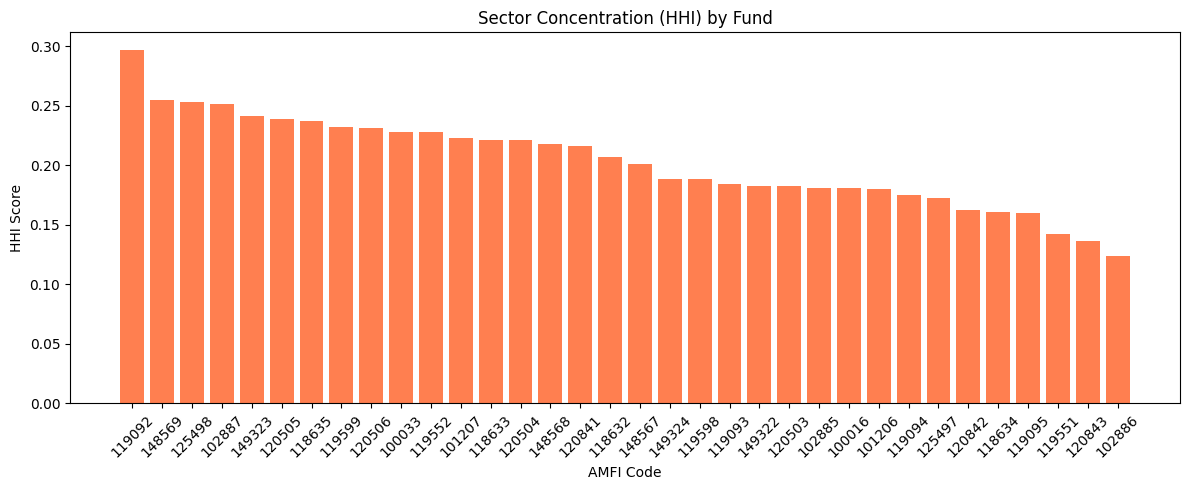

HHI chart saved


In [5]:
# ── TASK 6: Sector HHI ───────────────────────────────────────────────
hhi_rows = []
for code, grp in holdings.groupby("amfi_code"):
    weights = grp.groupby("sector")["weight_pct"].sum()
    weights = weights / weights.sum()
    hhi = (weights ** 2).sum()
    hhi_rows.append({"amfi_code": code, "HHI": round(hhi, 4)})

hhi_df = pd.DataFrame(hhi_rows).sort_values("HHI", ascending=False)
hhi_df.to_csv(PROCESSED / "sector_hhi.csv", index=False)
print("Sector HHI done")
print(hhi_df.head(10))

# HHI Chart
plt.figure(figsize=(12,5))
plt.bar(hhi_df["amfi_code"].astype(str), hhi_df["HHI"], color="coral")
plt.title("Sector Concentration (HHI) by Fund")
plt.xlabel("AMFI Code")
plt.ylabel("HHI Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PROCESSED / "sector_hhi_chart.png", dpi=150)
plt.show()
print("HHI chart saved")

## Advanced Analytics — 5 Key Insights

1. **Highest VaR funds** — amfi_code 101207 has the worst VaR (-2.6%), meaning highest daily loss risk at 95% confidence
2. **Rolling Sharpe shows 2024 recovery** — most funds had negative Sharpe in early 2022, recovered strongly by 2025
3. **2024 cohort invested more** — avg SIP amount ₹1.07L with 9,254 transactions vs 2025's 3,794
4. **38 SIP investors are at-risk** — gaps >35 days between transactions indicate potential churn
5. **Fund 119092 most concentrated** — highest HHI (0.30), meaning heavy sector concentration and higher risk